In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from final_project_part3 import (
    load_london_stations,
    load_london_connections,
    build_london_graph,
    compare_pair,
    run_all_pairs_experiment,
)

In [3]:
stations = load_london_stations("london_stations.csv")
connections = load_london_connections("london_connections.csv")
G, edge_lines = build_london_graph(stations, connections)

print(len(stations))
print(len(connections))
print(G.number_of_nodes())

302
406
302


In [4]:
sample = compare_pair(G, stations, edge_lines, 11, 163)
sample

{'source': 11,
 'dest': 163,
 'source_name': 'Baker Street',
 'dest_name': 'Marylebone',
 'dijkstra_runtime_ns': 286900,
 'astar_runtime_ns': 276000,
 'dijkstra_visited': 2,
 'astar_visited': 2,
 'dijkstra_popped': 2,
 'astar_popped': 2,
 'dijkstra_relaxations': 7,
 'astar_relaxations': 7,
 'distance': 0.4152661861393869,
 'path_edges': 1,
 'transfers': 0,
 'lines_used': 1,
 'same_line': True}

In [5]:
results = run_all_pairs_experiment(G, stations, edge_lines)
df = pd.DataFrame(results)

df.head()
df.shape

(90902, 17)

In [6]:
(df["dijkstra_runtime_ns"] > 0).all(), (df["astar_runtime_ns"] > 0).all()

(np.True_, np.True_)

In [7]:
df.to_csv("part3_results.csv", index=False)

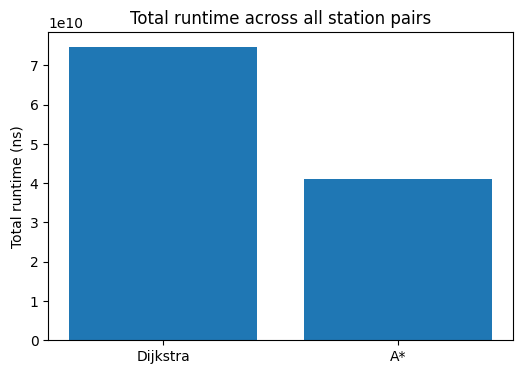

In [8]:
runtime_summary = pd.DataFrame({
    "algorithm": ["Dijkstra", "A*"],
    "total_runtime_ns": [
        df["dijkstra_runtime_ns"].sum(),
        df["astar_runtime_ns"].sum()
    ]
})

plt.figure(figsize=(6, 4))
plt.bar(runtime_summary["algorithm"], runtime_summary["total_runtime_ns"])
plt.ylabel("Total runtime (ns)")
plt.title("Total runtime across all station pairs")
plt.show()

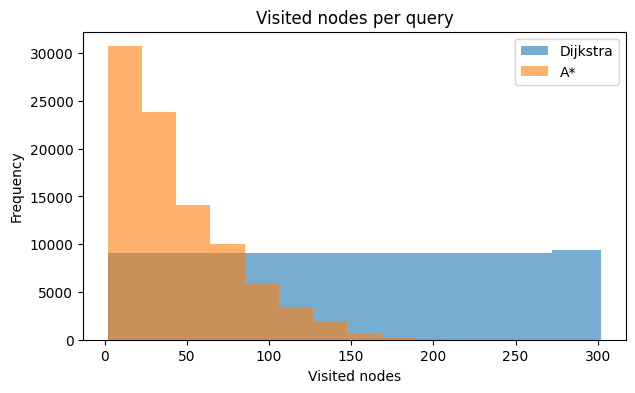

In [9]:
plt.figure(figsize=(7, 4))
plt.hist(df["dijkstra_visited"], alpha=0.6, label="Dijkstra")
plt.hist(df["astar_visited"], alpha=0.6, label="A*")
plt.xlabel("Visited nodes")
plt.ylabel("Frequency")
plt.title("Visited nodes per query")
plt.legend()
plt.show()

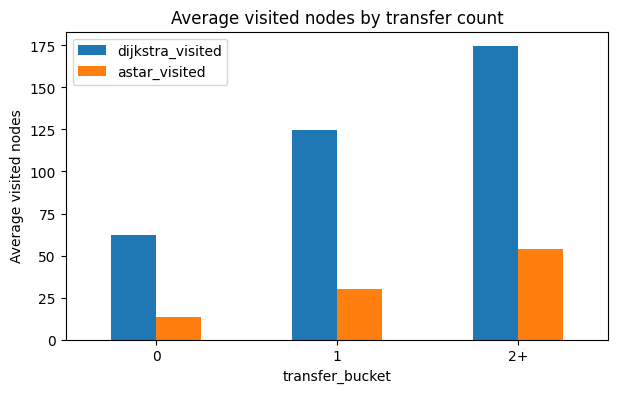

In [10]:
def transfer_bucket(t):
    if t == 0:
        return "0"
    elif t == 1:
        return "1"
    else:
        return "2+"

df["transfer_bucket"] = df["transfers"].apply(transfer_bucket)

grouped = df.groupby("transfer_bucket")[["dijkstra_visited", "astar_visited"]].mean()

grouped.plot(kind="bar", figsize=(7, 4))
plt.ylabel("Average visited nodes")
plt.title("Average visited nodes by transfer count")
plt.xticks(rotation=0)
plt.show()

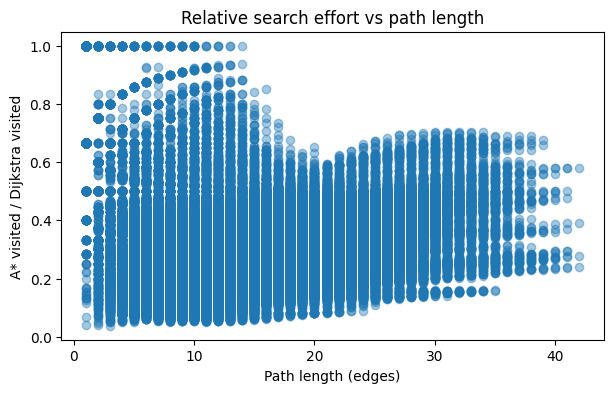

In [11]:
df["visited_ratio"] = df["astar_visited"] / df["dijkstra_visited"]

plt.figure(figsize=(7, 4))
plt.scatter(df["path_edges"], df["visited_ratio"], alpha=0.4)
plt.xlabel("Path length (edges)")
plt.ylabel("A* visited / Dijkstra visited")
plt.title("Relative search effort vs path length")
plt.show()

In [12]:
print(df["dijkstra_runtime_ns"].mean(), df["astar_runtime_ns"].mean())
print(df["dijkstra_visited"].mean(), df["astar_visited"].mean())

821900.819563926 453188.066269169
152.0 44.288189478779344
